___

<a href='http://www.pieriandata.com'><img src='../Pierian_Data_Logo.png'/></a>
___
<center><em>Авторские права принадлежат Pierian Data Inc.</em></center>
<center><em>Для дополнительной информации посетите наш сайт <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>

# Анализ и кластеризация стран


Источник данных: все данные былы созданы на основе данных следующего источника: 
https://www.cia.gov/library/publications/the-world-factbook/docs/faqs.html

## Цель: 

### Найти похожие между собой страны и регионы, экспериментируя с различным количеством кластеров. <br><br> Что означают полученные кластеры? <br><br> *Замечание: в этой задаче нет 100% правильных ответов, в видео-лекции мы обсуждаем один из вариантов интерпретации результатов.*

----

## Импорт библиотек и загрузка данных

**Задание: Запустите ячейки ниже для импорта библиотек и загрузки данных из файла в датайфрейм Pandas.**

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
df = pd.read_csv('../DATA/CIA_Country_Facts.csv')

## Исследование данных (Exploratory Data Analysis)

**Задание: посмотрите на строки и колонки в данных, в том числе на типы данных для колонок.**

In [66]:
# Напишите Ваш код в этой ячейке
df.head()

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,48.0,0.00,23.06,163.07,700.0,36.0,3.2,12.13,0.22,87.65,1.0,46.60,20.34,0.380,0.240,0.380
1,Albania,EASTERN EUROPE,3581655,28748,124.6,1.26,-4.93,21.52,4500.0,86.5,71.2,21.09,4.42,74.49,3.0,15.11,5.22,0.232,0.188,0.579
2,Algeria,NORTHERN AFRICA,32930091,2381740,13.8,0.04,-0.39,31.00,6000.0,70.0,78.1,3.22,0.25,96.53,1.0,17.14,4.61,0.101,0.600,0.298
3,American Samoa,OCEANIA,57794,199,290.4,58.29,-20.71,9.27,8000.0,97.0,259.5,10.00,15.00,75.00,2.0,22.46,3.27,NaN,NaN,NaN
4,Andorra,WESTERN EUROPE,71201,468,152.1,0.00,6.60,4.05,19000.0,100.0,497.2,2.22,0.00,97.78,3.0,8.71,6.25,NaN,NaN,NaN


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Country                             227 non-null    object 
 1   Region                              227 non-null    object 
 2   Population                          227 non-null    int64  
 3   Area (sq. mi.)                      227 non-null    int64  
 4   Pop. Density (per sq. mi.)          227 non-null    float64
 5   Coastline (coast/area ratio)        227 non-null    float64
 6   Net migration                       224 non-null    float64
 7   Infant mortality (per 1000 births)  224 non-null    float64
 8   GDP ($ per capita)                  226 non-null    float64
 9   Literacy (%)                        209 non-null    float64
 10  Phones (per 1000)                   223 non-null    float64
 11  Arable (%)                          225 non-n

In [68]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Population,227.0,2.874028e+07,1.178913e+08,7026.000,437624.00000,4786994.000,1.749777e+07,1.313974e+09
Area (sq. mi.),227.0,5.982270e+05,1.790282e+06,2.000,4647.50000,86600.000,4.418110e+05,1.707520e+07
Pop. Density (per sq. mi.),227.0,3.790471e+02,1.660186e+03,0.000,29.15000,78.800,1.901500e+02,1.627150e+04
Coastline (coast/area ratio),227.0,2.116533e+01,7.228686e+01,0.000,0.10000,0.730,1.034500e+01,8.706600e+02
Net migration,224.0,3.812500e-02,4.889269e+00,-20.990,-0.92750,0.000,9.975000e-01,2.306000e+01
Infant mortality (per 1000 births),224.0,3.550696e+01,3.538990e+01,2.290,8.15000,21.000,5.570500e+01,1.911900e+02
GDP ($ per capita),226.0,9.689823e+03,1.004914e+04,500.000,1900.00000,5550.000,1.570000e+04,5.510000e+04
Literacy (%),209.0,8.283828e+01,1.972217e+01,17.600,70.60000,92.500,9.800000e+01,1.000000e+02
Phones (per 1000),223.0,2.360614e+02,2.279918e+02,0.200,37.80000,176.200,3.896500e+02,1.035600e+03
Arable (%),225.0,1.379711e+01,1.304040e+01,0.000,3.22000,10.420,2.000000e+01,6.211000e+01


# Визуализация данных

Давайте построим некоторые графики для визуализации данных. Кроме предложенных графиков ниже, Вы также можете создать любые дополнительные визуализации данных, которые покажутся Вам интересными!

**Задание: постройте гистограмму для колонки Population.**

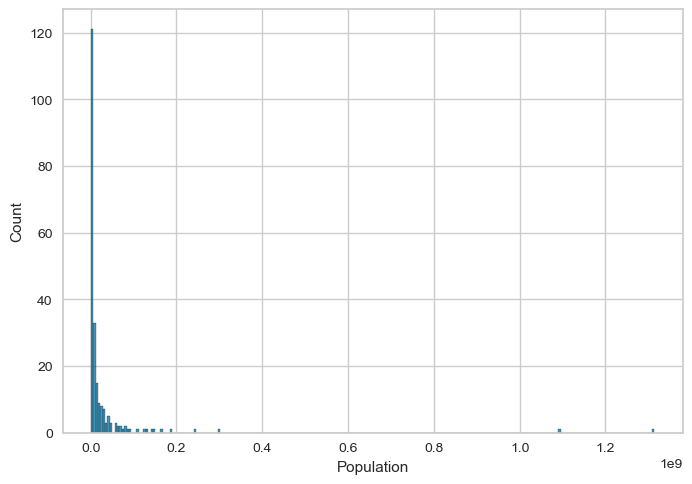

In [69]:
# Напишите Ваш код в этой ячейке
sns.histplot(data=df, x='Population')

plt.show();

**Задание: Вы заметите, что гистограмма очень перекошена из-за нескольких очень больших стран. Поменяйте график таким образом, чтобы показывать только страны с населением меньше 0.5 миллиарда людей.**

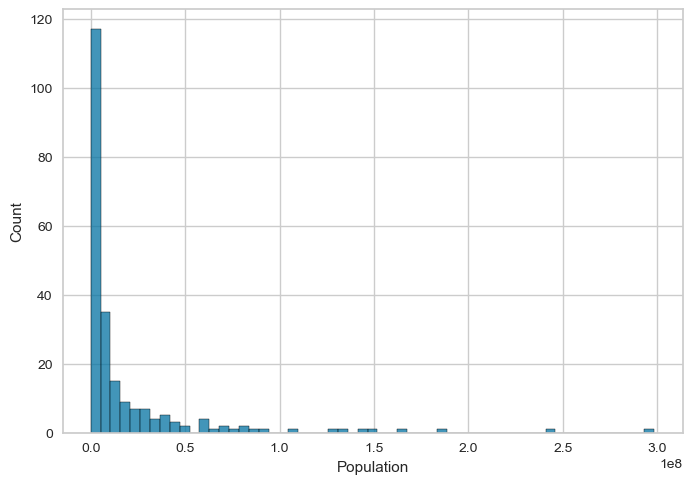

In [70]:
# Напишите Ваш код в этой ячейке
sns.histplot(data=df[df['Population'] < 0.5 * 10**9], x='Population')

plt.show();

**Задание: далее исследуем GDP (ВВП - Валовый Внутренний Продукт) и регионы (Regions). Постройте график barchart, на котором изобразите среднее ВВП на душу населения (GDP per Capita) для каждого региона.**

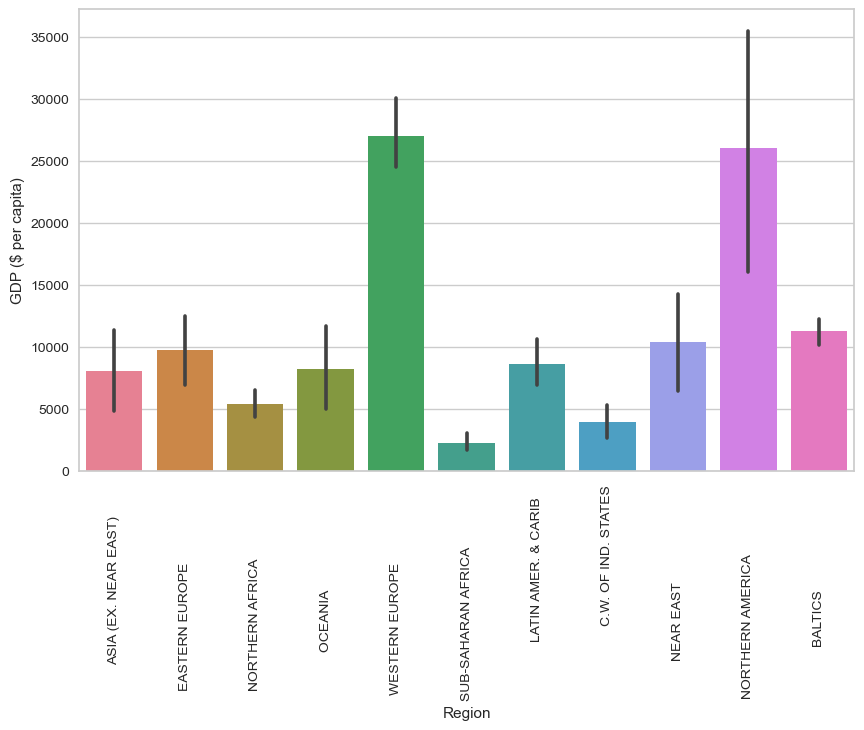

In [71]:
# Напишите Ваш код в этой ячейке
plt.figure(figsize=(10,6))
sns.barplot(data=df, y='GDP ($ per capita)', x='Region', hue='Region', estimator=np.mean)
plt.xticks(rotation=90)

plt.show();

**Задание: Постройте график scatterplot для визуализации связи между колонками "кол-во телефонов на одну тысячу человек" и "ВВП на душу населения". Раскрасьте этот график разными цветами по колонке Region.**

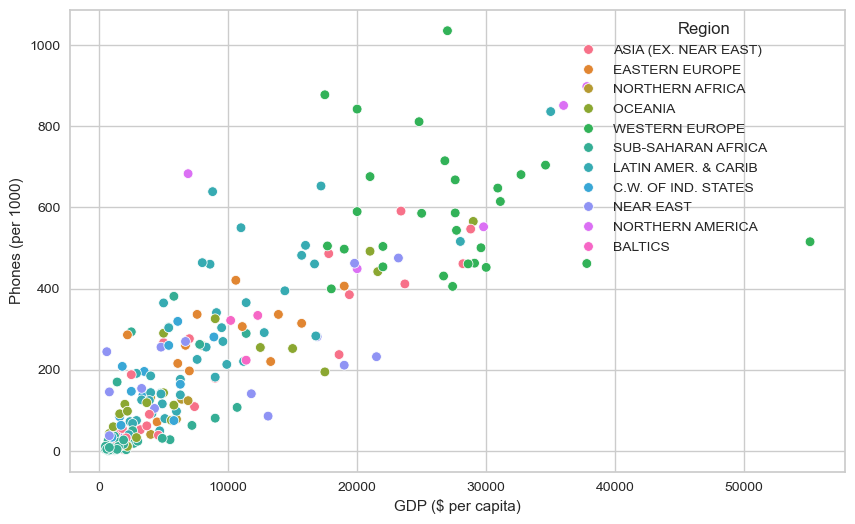

In [72]:
# Напишите Ваш код в этой ячейке
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, y='Phones (per 1000)', x='GDP ($ per capita)', hue='Region')

plt.show();

**Задание: Постройте график scatterplot для колонок "GDP per Capita" и "Literacy" (раскрасьте график по колонке Region). Какие выводы можно сделать из этого графика?**

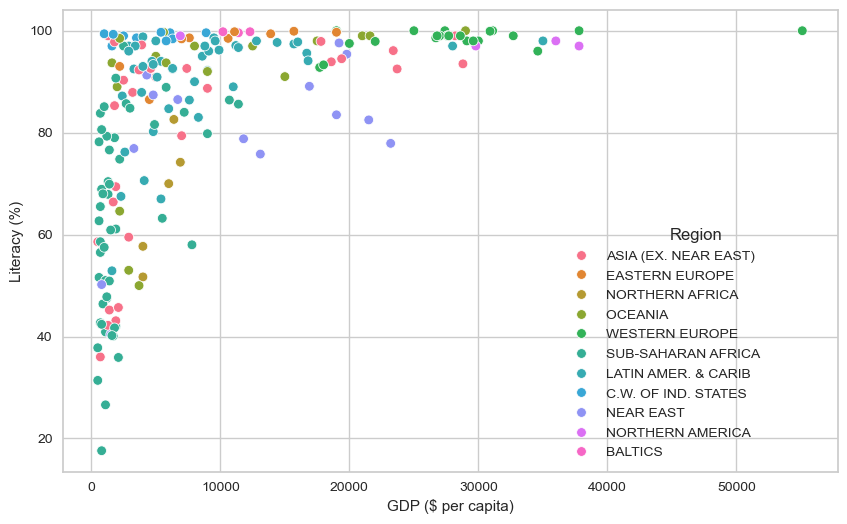

In [73]:
# Напишите Ваш код в этой ячейке
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, y='Literacy (%)', x='GDP ($ per capita)', hue='Region')

plt.show();

**Задание: Постройте тепловую карту Heatmap для корреляций между колонками в датафрейме.**

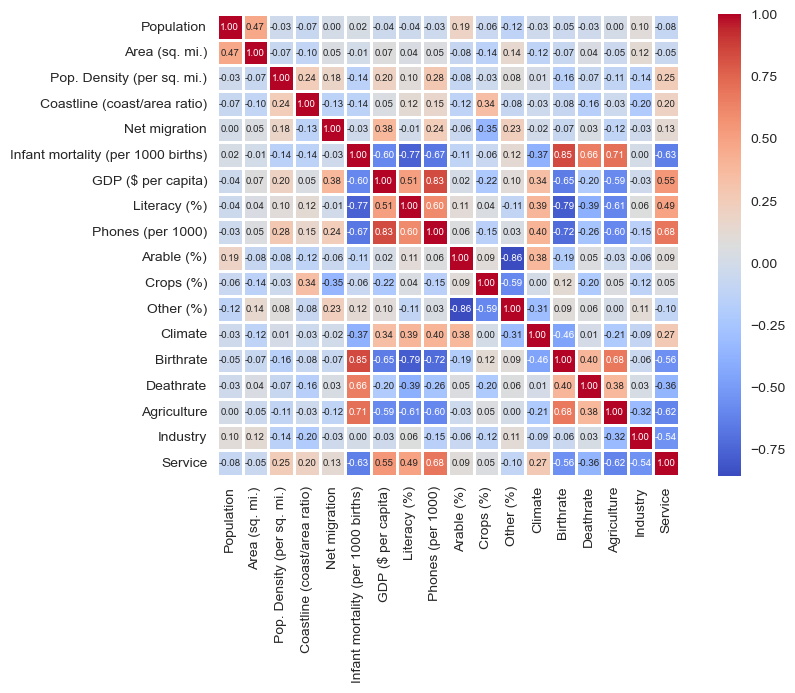

In [74]:
# Напишите Ваш код в этой ячейке
plt.figure(figsize=(10, 6))
sns.heatmap(data=df.corr(numeric_only=True), cmap='coolwarm', square=True, lw=1, annot=True, annot_kws={'fontsize':7}, fmt='.2f')

plt.show();

**Задание: Seaborn может автоматически выполнять иерархическую кластеризацию данных с помощью функции clustermap(). Постройте график clustermap для корреляций между колонками датафрейма.**

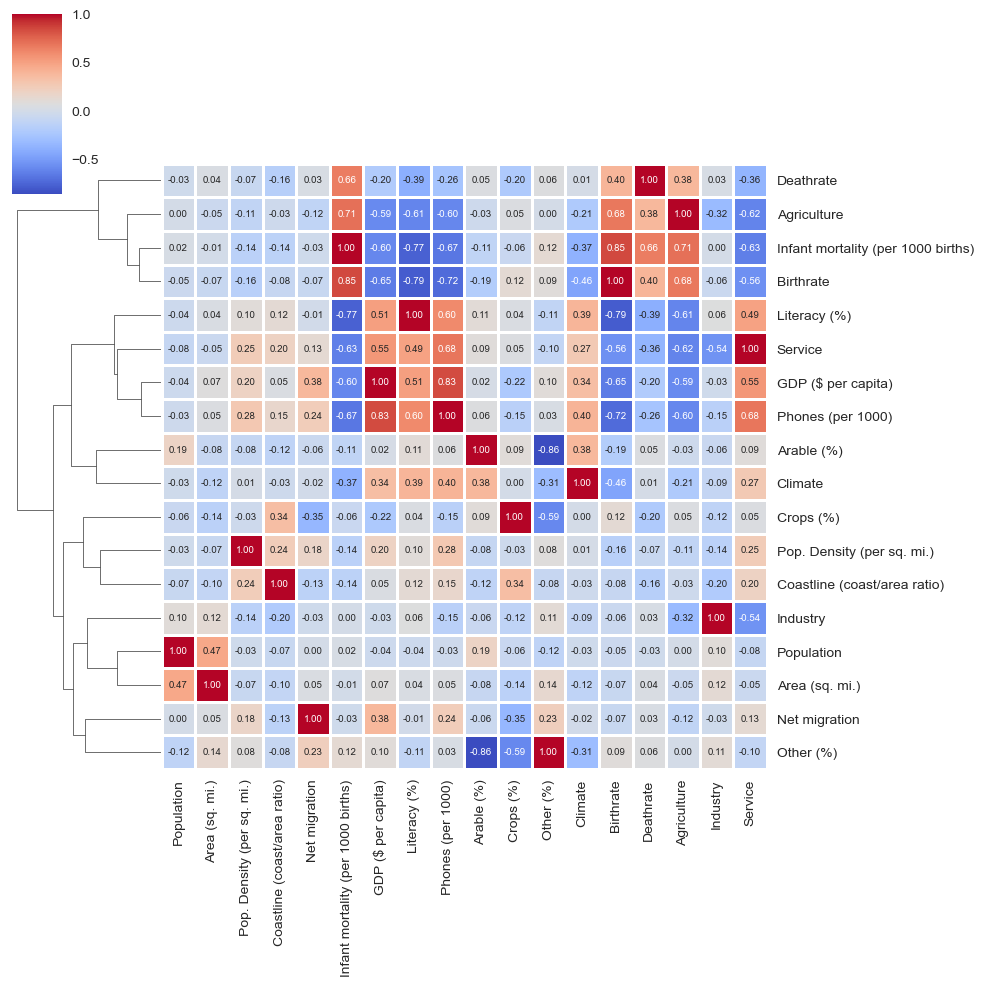

In [75]:
# Напишите Ваш код в этой ячейке
sns.clustermap(data=df.corr(numeric_only=True), cmap='coolwarm', lw=1, annot=True, annot_kws={'fontsize':7}, fmt='.2f', col_cluster=False)

plt.show();

-----

## Подготовка данных и модель данных

Давайте подготовим наши данные для кластеризации с помощью метода К-средних!

### Отсутствующие данные (Missing Data)

**Задание: Постройте отчёт - сколько строк имеют отсутствующие значения в той или иной колонке.**

In [76]:
# Напишите Ваш код в этой ячейке
df.isna().sum()

Country                                0
Region                                 0
Population                             0
Area (sq. mi.)                         0
Pop. Density (per sq. mi.)             0
Coastline (coast/area ratio)           0
Net migration                          3
Infant mortality (per 1000 births)     3
GDP ($ per capita)                     1
Literacy (%)                          18
Phones (per 1000)                      4
Arable (%)                             2
Crops (%)                              2
Other (%)                              2
Climate                               22
Birthrate                              3
Deathrate                              4
Agriculture                           15
Industry                              16
Service                               15
dtype: int64

**Задание: Для каких стран в колонке Agriculture значения NaN? Что эти страны имеют общего между собой?**

In [77]:
df[df['Agriculture'].isna()]['Country']

3            American Samoa
4                   Andorra
78                Gibraltar
80                Greenland
83                     Guam
134                 Mayotte
140              Montserrat
144                   Nauru
153      N. Mariana Islands
171            Saint Helena
174    St Pierre & Miquelon
177              San Marino
208       Turks & Caicos Is
221       Wallis and Futuna
223          Western Sahara
Name: Country, dtype: object

**Задание: Вы наверняка заметили, что большинство этих стран являются маленькими островами, кроме Гринландии и Западной Сахары. Замените для этих стран отсутствующие значения нулями (во всех колонках), потому что это очень маленькие страны. У Вас должно получиться 15 таких стран. В качестве подсказки вспомните, что мы можем применять вот такой синтаксис:**

    df[df['feature'].isnull()]
    

In [78]:
# Напишите Ваш код в этой ячейке
df[df['Agriculture'].isna()] = df[df['Agriculture'].isna()].fillna(0)

**Задание: Проверьте заново, в каких колонках сколько строк имеют неопределённые значения:**

In [79]:
# Напишите Ваш код в этой ячейке
df.isna().sum()

Country                                0
Region                                 0
Population                             0
Area (sq. mi.)                         0
Pop. Density (per sq. mi.)             0
Coastline (coast/area ratio)           0
Net migration                          1
Infant mortality (per 1000 births)     1
GDP ($ per capita)                     0
Literacy (%)                          13
Phones (per 1000)                      2
Arable (%)                             1
Crops (%)                              1
Other (%)                              1
Climate                               18
Birthrate                              1
Deathrate                              2
Agriculture                            0
Industry                               1
Service                                1
dtype: int64

**Задание: Обратите внимание, что колонка "climate" пустая для нескольких стран. Но для всех стран заполнена колонка Region! Пользуясь этим, замените отсутствующие значения колонки Climate на средние значения этой колонки, где усреднение выполняется для соответствующего региона.**

Подсказка о том, как это можно сделать: https://stackoverflow.com/questions/19966018/pandas-filling-missing-values-by-mean-in-each-group


In [80]:
# Напишите Ваш код в этой ячейке

In [81]:
df['Climate'] = df['Climate'].fillna(df.groupby('Region')['Climate'].transform('mean'))

**Задание: Проверьте заново, сколько теперь отсутствующих значений.**

In [82]:
# Напишите Ваш код в этой ячейке
df.isna().sum()

Country                                0
Region                                 0
Population                             0
Area (sq. mi.)                         0
Pop. Density (per sq. mi.)             0
Coastline (coast/area ratio)           0
Net migration                          1
Infant mortality (per 1000 births)     1
GDP ($ per capita)                     0
Literacy (%)                          13
Phones (per 1000)                      2
Arable (%)                             1
Crops (%)                              1
Other (%)                              1
Climate                                0
Birthrate                              1
Deathrate                              2
Agriculture                            0
Industry                               1
Service                                1
dtype: int64

**Задание: Для колонки "Literacy percentage" примените такой же метод, что и ранее для колонки Climate. Замените отсутствующие значения колонки Literacy % на средние значения этой колонки для соответствующего региона.**

In [83]:
df[df['Literacy (%)'].isnull()]

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
25,Bosnia & Herzegovina,EASTERN EUROPE,4498976,51129,88.0,0.04,0.31,21.05,6100.0,NaN,215.4,13.60,2.96,83.44,4.000000,8.77,8.27,0.142,0.308,0.550
66,Faroe Islands,WESTERN EUROPE,47246,1399,33.8,79.84,1.41,6.24,22000.0,NaN,503.8,2.14,0.00,97.86,2.826087,14.05,8.70,0.270,0.110,0.620
74,Gaza Strip,NEAR EAST,1428757,360,3968.8,11.11,1.60,22.93,600.0,NaN,244.3,28.95,21.05,50.00,3.000000,39.45,3.80,0.030,0.283,0.687
85,Guernsey,WESTERN EUROPE,65409,78,838.6,64.10,3.84,4.71,20000.0,NaN,842.4,NaN,NaN,NaN,3.000000,8.81,10.01,0.030,0.100,0.870
99,Isle of Man,WESTERN EUROPE,75441,572,131.9,27.97,5.36,5.93,21000.0,NaN,676.0,9.00,0.00,91.00,3.000000,11.05,11.19,0.010,0.130,0.860
104,Jersey,WESTERN EUROPE,91084,116,785.2,60.34,2.76,5.24,24800.0,NaN,811.3,0.00,0.00,100.00,3.000000,9.30,9.28,0.050,0.020,0.930
108,Kiribati,OCEANIA,105432,811,130.0,140.94,0.00,48.52,800.0,NaN,42.7,2.74,50.68,46.58,2.000000,30.65,8.26,0.089,0.242,0.668
123,Macedonia,EASTERN EUROPE,2050554,25333,80.9,0.00,-1.45,10.09,6700.0,NaN,260.0,22.26,1.81,75.93,3.000000,12.02,8.77,0.118,0.319,0.563
185,Slovakia,EASTERN EUROPE,5439448,48845,111.4,0.00,0.30,7.41,13300.0,NaN,220.1,30.16,2.62,67.22,3.000000,10.65,9.45,0.035,0.294,0.672
187,Solomon Islands,OCEANIA,552438,28450,19.4,18.67,0.00,21.29,1700.0,NaN,13.4,0.64,2.00,97.36,2.000000,30.01,3.92,0.420,0.110,0.470


In [84]:
# Напишите Ваш код в этой ячейке
df['Literacy (%)'] = df['Literacy (%)'].fillna(df.groupby('Region')['Literacy (%)'].transform('mean'))

**Задание: Проверьте заново, сколько теперь отсутствующих значений.**

In [85]:
# Напишите Ваш код в этой ячейке
df.isna().sum().sort_values(ascending=False)

Phones (per 1000)                     2
Deathrate                             2
Arable (%)                            1
Industry                              1
Birthrate                             1
Other (%)                             1
Crops (%)                             1
Service                               1
Infant mortality (per 1000 births)    1
Net migration                         1
GDP ($ per capita)                    0
Literacy (%)                          0
Region                                0
Coastline (coast/area ratio)          0
Climate                               0
Pop. Density (per sq. mi.)            0
Area (sq. mi.)                        0
Agriculture                           0
Population                            0
Country                               0
dtype: int64

**Задание (Опционально): Теперь данные отсутствуют только для нескольких стран. Либо удалите такие страны, ИЛИ обработайте эти отсутствующие значения по какой-либо выбранной Вами методологии. Чтобы сэкономить Ваше время, мы удалим эти страны.**

In [86]:
# Напишите Ваш код в этой ячейке
df[df.isna().any(axis=1)]

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
47,Cook Islands,OCEANIA,21388,240,89.1,50.00,NaN,NaN,5000.0,95.000000,289.9,17.39,13.04,69.57,2.000000,21.00,NaN,0.151,0.096,0.753
52,Cyprus,NEAR EAST,784301,9250,84.8,7.01,0.43,7.18,19200.0,97.600000,NaN,7.79,4.44,87.77,3.000000,12.56,7.68,0.037,0.198,0.765
58,East Timor,ASIA (EX. NEAR EAST),1062777,15007,70.8,4.70,0.00,47.41,500.0,58.600000,NaN,4.71,0.67,94.62,2.000000,26.99,6.24,0.085,0.231,0.684
85,Guernsey,WESTERN EUROPE,65409,78,838.6,64.10,3.84,4.71,20000.0,94.291667,842.4,NaN,NaN,NaN,3.000000,8.81,10.01,0.030,0.100,0.870
138,Monaco,WESTERN EUROPE,32543,2,16271.5,205.00,7.75,5.43,27000.0,99.000000,1035.6,0.00,0.00,100.00,2.826087,9.19,12.91,0.170,NaN,NaN
181,Serbia,EASTERN EUROPE,9396411,88361,106.3,0.00,-1.33,12.89,2200.0,93.000000,285.8,33.35,3.20,63.45,3.111111,NaN,NaN,0.166,0.255,0.579


In [87]:
columns_with_na = df.columns[df.isna().any()].tolist()
columns_with_na

['Net migration',
 'Infant mortality (per 1000 births)',
 'Phones (per 1000)',
 'Arable (%)',
 'Crops (%)',
 'Other (%)',
 'Birthrate',
 'Deathrate',
 'Industry',
 'Service']

In [88]:
from sklearn.impute import SimpleImputer

In [89]:
imputer = SimpleImputer(strategy='mean')

In [90]:
df[columns_with_na] = imputer.fit_transform(df[columns_with_na])

## Подготовка данных с признаками

**Задание: пришло время подготовить данные для кластеризации. Колонка Country является уникальным идентификатором, поэтому эта колонка не будет полезной для кластеризации, поскольку она содержит уникальные значения для каждой строки. При создании датафрейма с наборами признаков X удалите эту колонку Country.**

In [91]:
# Напишите Ваш код в этой ячейке
X = df.drop('Country', axis=1)

**Задание: Создайте набор признаков X, причём колонка Region всё ещё является категориальной, поэтому для этой колонки создайте дамми-переменные с помощью Pandas.**

In [92]:
# Напишите Ваш код в этой ячейке
X = pd.get_dummies(X)

In [93]:
X.head()

,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),...,Region_BALTICS,Region_C.W. OF IND. STATES,Region_EASTERN EUROPE,Region_LATIN AMER. & CARIB,Region_NEAR EAST,Region_NORTHERN AFRICA,Region_NORTHERN AMERICA,Region_OCEANIA,Region_SUB-SAHARAN AFRICA,Region_WESTERN EUROPE
0,31056997,647500,48.0,0.00,23.06,163.07,700.0,36.0,3.2,12.13,...,False,False,False,False,False,False,False,False,False,False
1,3581655,28748,124.6,1.26,-4.93,21.52,4500.0,86.5,71.2,21.09,...,False,False,True,False,False,False,False,False,False,False
2,32930091,2381740,13.8,0.04,-0.39,31.00,6000.0,70.0,78.1,3.22,...,False,False,False,False,False,True,False,False,False,False
3,57794,199,290.4,58.29,-20.71,9.27,8000.0,97.0,259.5,10.00,...,False,False,False,False,False,False,False,True,False,False
4,71201,468,152.1,0.00,6.60,4.05,19000.0,100.0,497.2,2.22,...,False,False,False,False,False,False,False,False,False,True


### Масштабирование данных

**Задание: Поскольку некоторые колонки измеряются в процентах, а некоторые в абсолютных значениях, то выполните масштабирование признаков с помощью Sklearn.**

In [94]:
# Напишите Ваш код в этой ячейке
from sklearn.preprocessing import StandardScaler

In [95]:
scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)

In [96]:
scaled_X

array([[ 0.01969468,  0.02758332, -0.19984434, ..., -0.31928318,
        -0.53830542, -0.37510468],
       [-0.21387688, -0.31879748, -0.15360296, ..., -0.31928318,
        -0.53830542, -0.37510468],
       [ 0.03561811,  0.99842051, -0.22048996, ..., -0.31928318,
        -0.53830542, -0.37510468],
       ...,
       [-0.06192308, -0.03933023, -0.20431152, ..., -0.31928318,
        -0.53830542, -0.37510468],
       [-0.14654488,  0.08642673, -0.21958445, ..., -0.31928318,
         1.85768146, -0.37510468],
       [-0.14029829, -0.11624192, -0.20992568, ..., -0.31928318,
         1.85768146, -0.37510468]])

### Создание и обучение модели Kmeans




**Задание: Напишите цикл for для создания и обучения нескольких моделей KMeans, проверяя количество кластеров K от 2 до 30. На каждом шаге цикла сохраняйте сумму квадратов расстояний от точек до центров кластеров (SSD - Sum of Squared Distances) для каждого значения K. Далее нанесите эти данные на график, изображая метрику SSD для различных значений К. Опционально: также можно построить график barplot с изменениями метрики SSD.**

In [97]:
import warnings
warnings.simplefilter(action='ignore')

In [98]:
# Напишите Ваш код в этой ячейке
from sklearn.cluster import KMeans

In [99]:
ssd = []

for k in range(2, 30):
    model = KMeans(n_clusters=k)
    model.fit(scaled_X)
    ssd.append(model.inertia_)

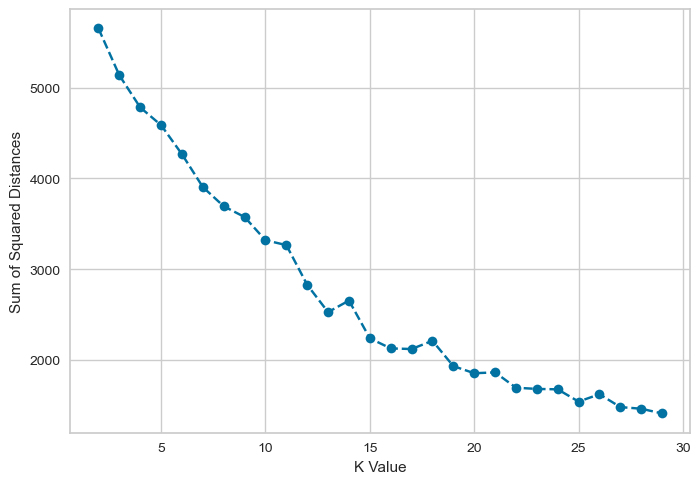

In [100]:
plt.plot(range(2, 30), ssd, 'o--')
plt.xlabel('K Value')
plt.ylabel('Sum of Squared Distances')

plt.show();

-----

# Интерпретация модели


**Задание: Какое значение K может быть хорошим выбором? Возможно таких значений несколько? Какие признаки влияют на формирование этих кластеров? Поскольку это обучение без учителя (unsupervised learning), здесь нет на 100% правильного ответа. Можете посмотреть видео-лекцию с решениями, где мы обсуждаем эту тему.**

In [101]:
# Выберите K на основе метода локтя, а также посмотрите какие признаки влияют на создение кластеров!

# Помните, здесь нет на 100% правильного ответа!

-----


#### Пример: выбираем K=3

**Можно сказать, что в точке K=3 падение метрики SSD более пологое (хотя метрика продолжает уменьшаться после этой точки). Как может выглядеть картина для K=3? Давайте посмотрим, какие признаки являются важными в случае 3 кластеров!**

In [102]:
model = KMeans(n_clusters=3)
model.fit(scaled_X)

KMeans(n_clusters=3)

In [103]:
model.labels_

array([0, 1, 2, 2, 1, 0, 2, 2, 2, 1, 2, 2, 1, 2, 2, 2, 0, 1, 1, 1, 2, 0,
       1, 0, 2, 1, 0, 2, 2, 2, 1, 0, 0, 0, 0, 0, 1, 2, 1, 0, 0, 2, 2, 2,
       0, 0, 0, 2, 2, 0, 1, 2, 2, 1, 1, 0, 2, 2, 2, 2, 2, 2, 0, 0, 1, 0,
       1, 2, 1, 1, 2, 2, 0, 0, 2, 2, 1, 0, 2, 1, 2, 2, 2, 2, 2, 1, 0, 0,
       2, 0, 2, 1, 1, 1, 0, 2, 2, 2, 1, 1, 2, 1, 2, 1, 1, 2, 1, 0, 2, 2,
       1, 2, 2, 0, 1, 2, 0, 0, 2, 1, 1, 1, 1, 1, 0, 0, 2, 2, 0, 1, 2, 2,
       0, 1, 0, 2, 2, 1, 1, 2, 2, 2, 0, 0, 2, 0, 1, 2, 2, 2, 2, 0, 0, 2,
       1, 2, 0, 2, 2, 2, 2, 2, 2, 1, 1, 2, 2, 2, 1, 1, 0, 2, 2, 2, 2, 2,
       2, 1, 0, 2, 0, 1, 2, 0, 1, 1, 1, 2, 0, 0, 1, 2, 0, 2, 0, 1, 1, 2,
       1, 0, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 1, 2, 1, 1, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 0, 0, 0])

In [104]:
X['K=3 Clusters'] = model.labels_

In [105]:
X.corr()['K=3 Clusters'].sort_values()

Deathrate                                    -0.733135
Region_SUB-SAHARAN AFRICA                    -0.681651
Infant mortality (per 1000 births)           -0.645049
Birthrate                                    -0.505725
Agriculture                                  -0.477444
Arable (%)                                   -0.166219
Net migration                                -0.156646
Region_WESTERN EUROPE                        -0.085625
Climate                                      -0.083988
Region_EASTERN EUROPE                        -0.064122
Population                                   -0.039615
Region_ASIA (EX. NEAR EAST)                  -0.037073
Region_BALTICS                               -0.031410
Area (sq. mi.)                               -0.008815
Pop. Density (per sq. mi.)                   -0.008535
Industry                                      0.020797
Region_C.W. OF IND. STATES                    0.031013
Region_NORTHERN AMERICA                       0.031787
Other (%) 

In [106]:
model = KMeans(n_clusters=15)
model.fit(scaled_X)
X['K=15 Clusters'] = model.labels_

In [107]:
X.corr()['K=15 Clusters'].sort_values()

Infant mortality (per 1000 births)           -0.471830
Birthrate                                    -0.414585
Agriculture                                  -0.360105
Region_SUB-SAHARAN AFRICA                    -0.332353
Region_ASIA (EX. NEAR EAST)                  -0.331094
Deathrate                                    -0.298533
Region_C.W. OF IND. STATES                   -0.232928
Industry                                     -0.232530
Region_BALTICS                               -0.181028
Population                                   -0.147915
Region_NEAR EAST                             -0.112248
Arable (%)                                   -0.087944
Region_LATIN AMER. & CARIB                   -0.055711
Area (sq. mi.)                                0.030513
Crops (%)                                     0.038940
Other (%)                                     0.066498
Net migration                                 0.108023
Climate                                       0.110670
Service   

In [108]:
from sklearn.metrics import silhouette_score

In [109]:
silhouettes = []

for k in range(2, 30):
    model = KMeans(n_clusters=k)
    model.fit(scaled_X)
    silhouettes.append(silhouette_score(scaled_X, model.labels_))

In [110]:
from yellowbrick.cluster import SilhouetteVisualizer

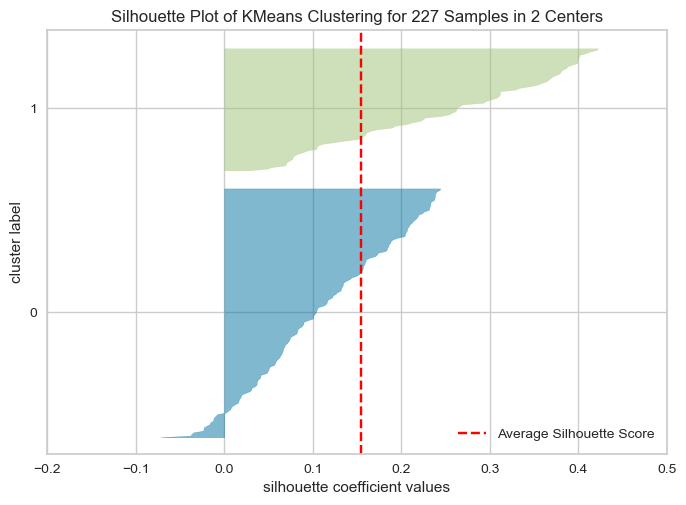

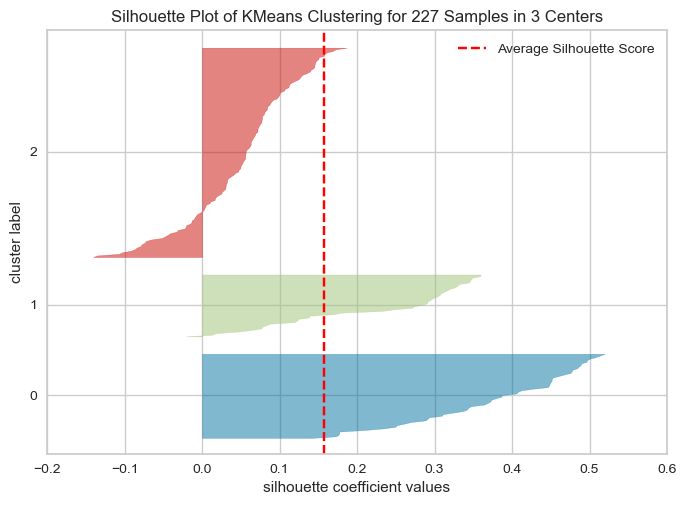

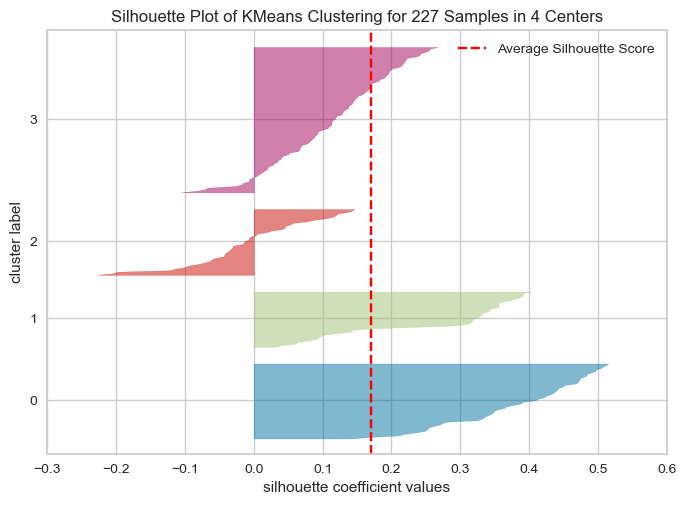

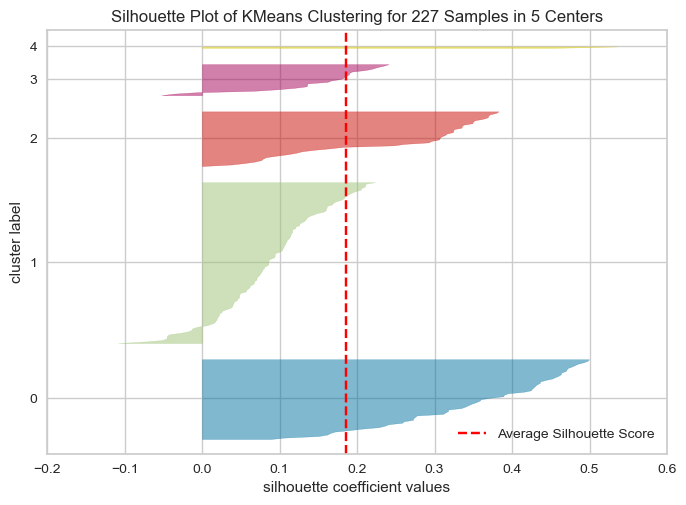

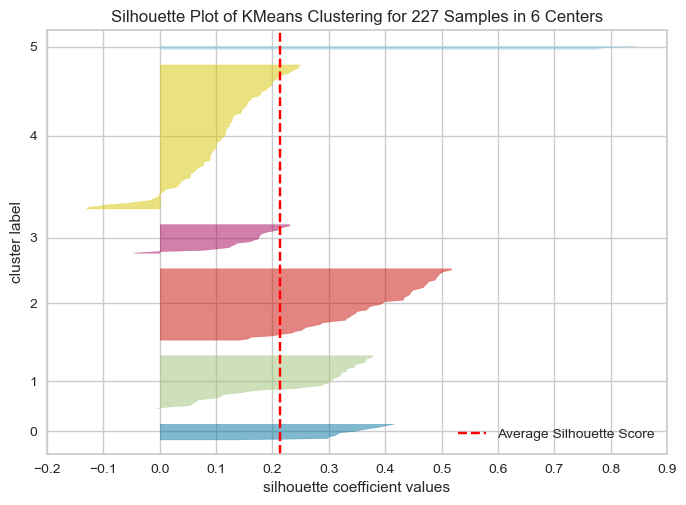

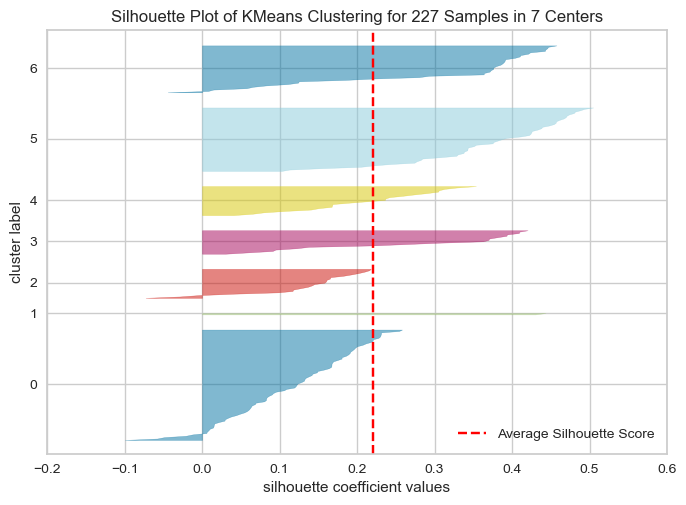

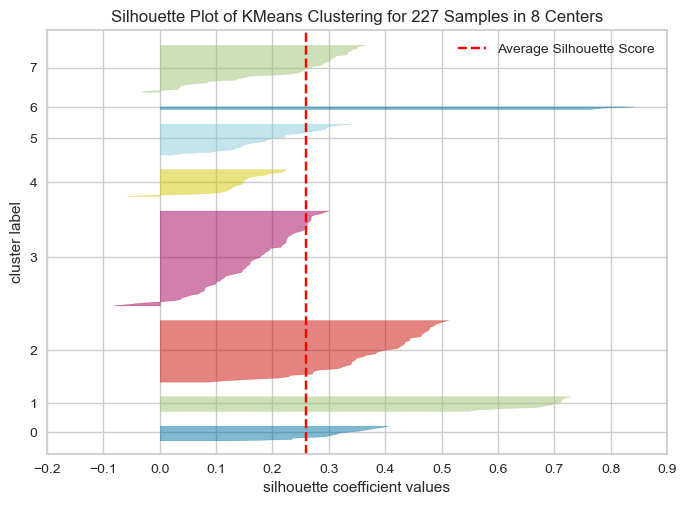

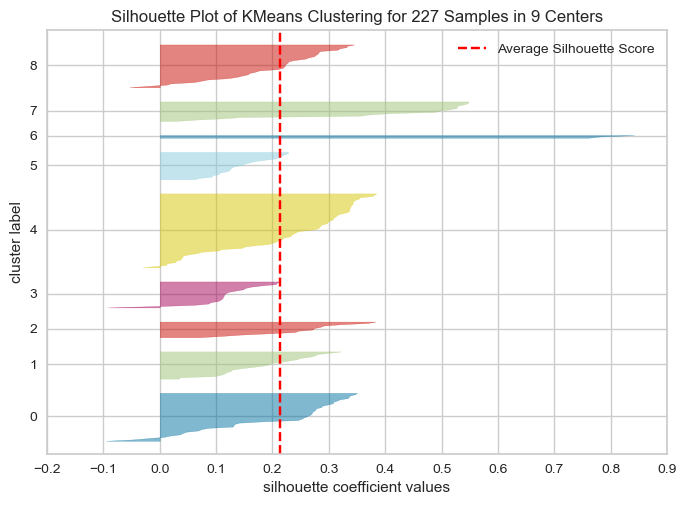

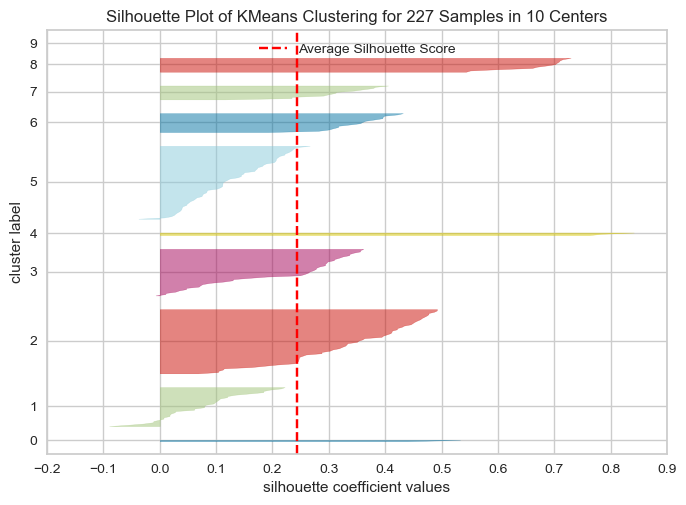

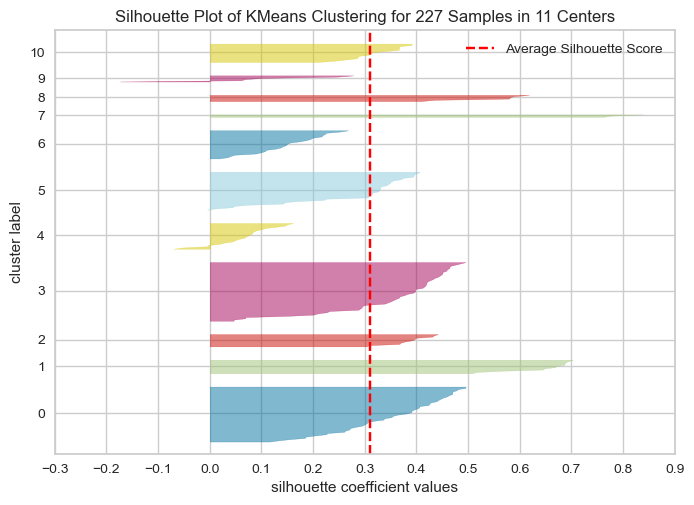

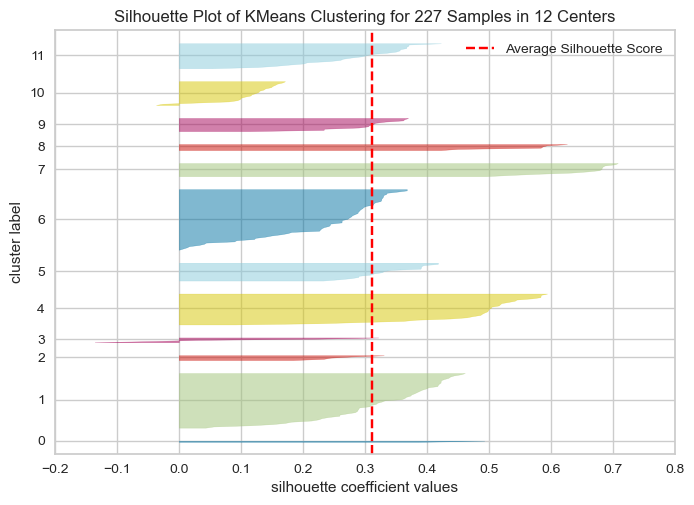

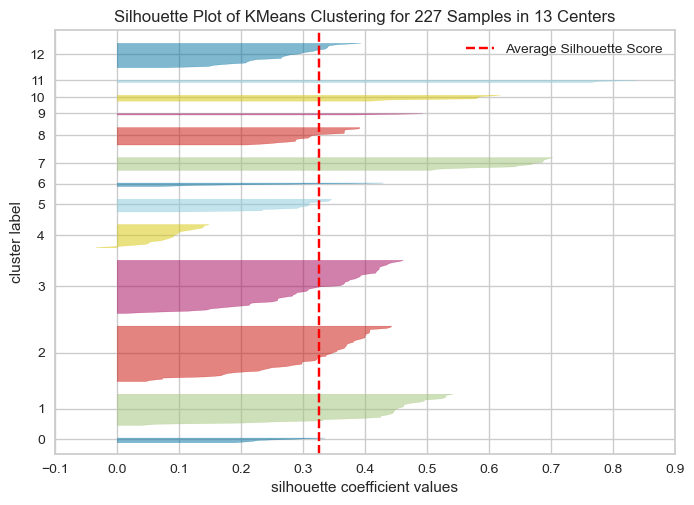

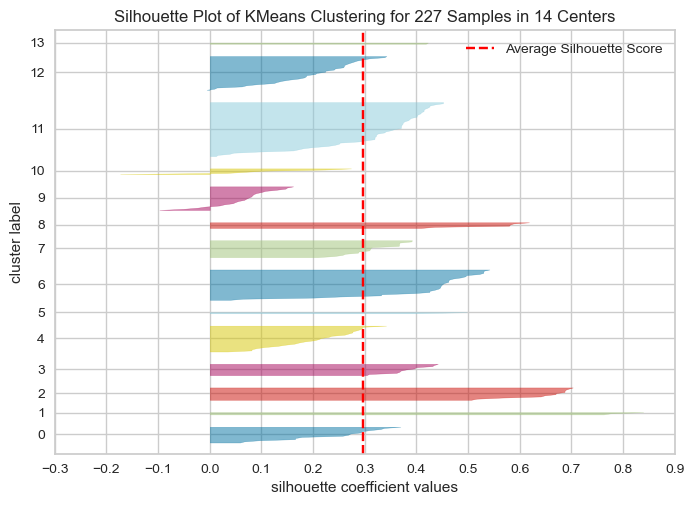

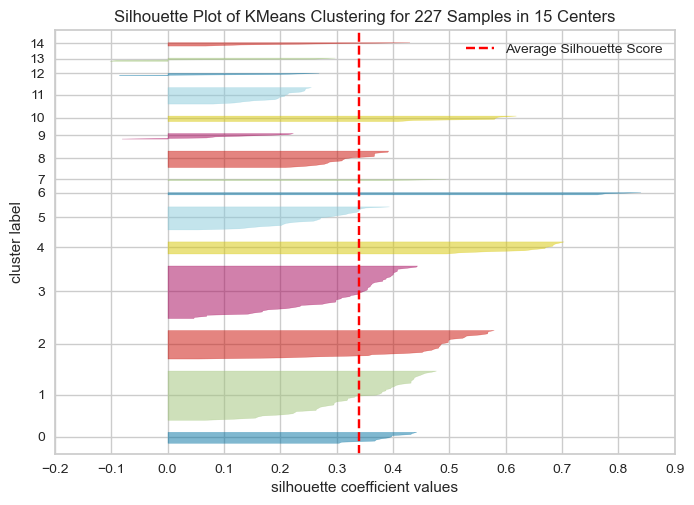

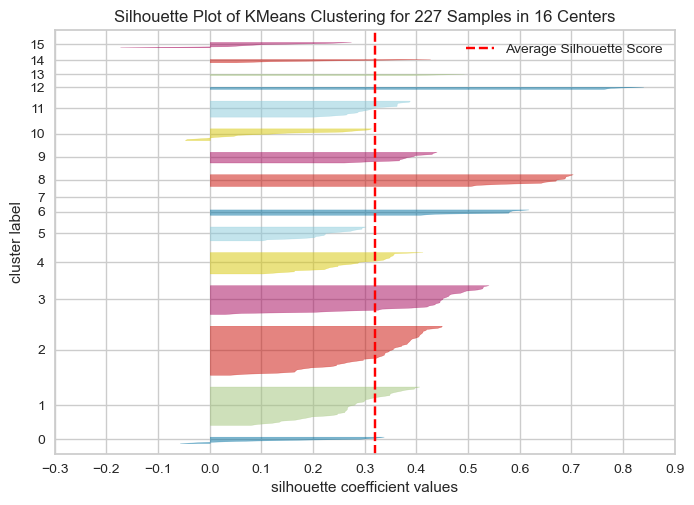

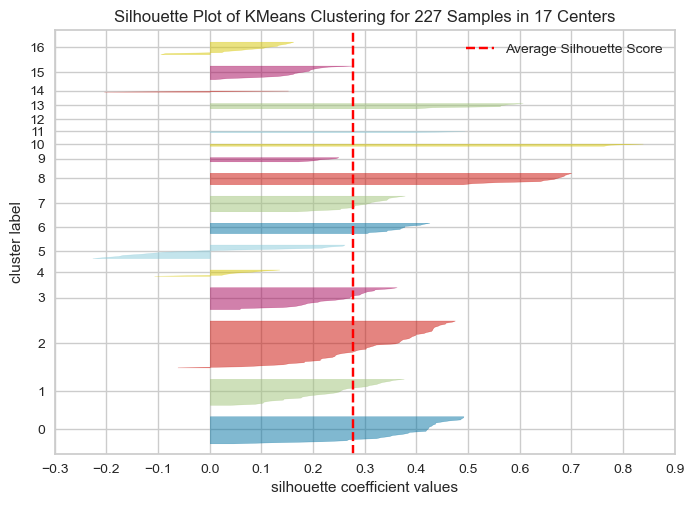

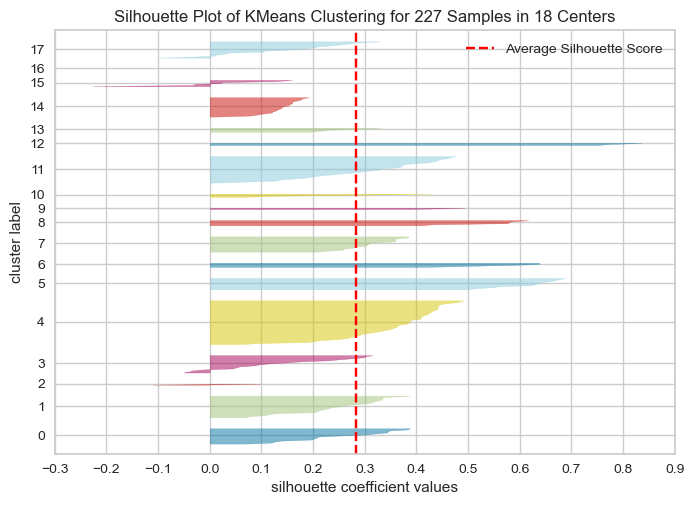

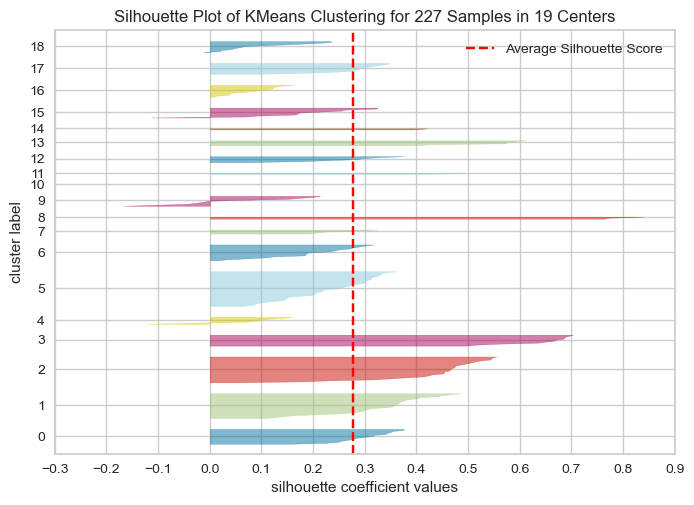

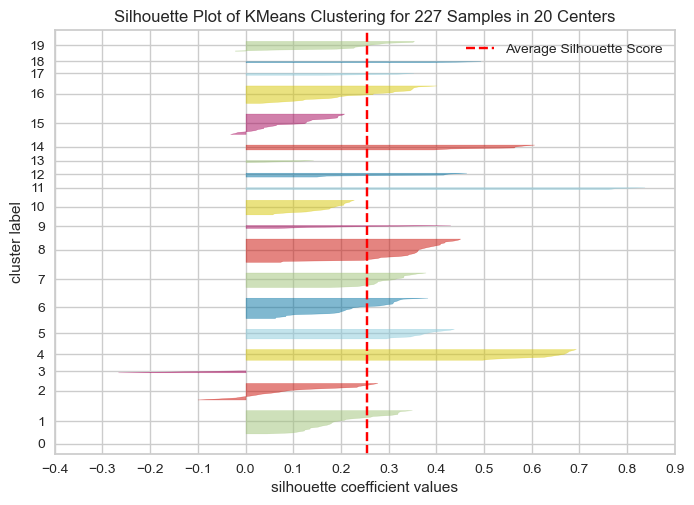

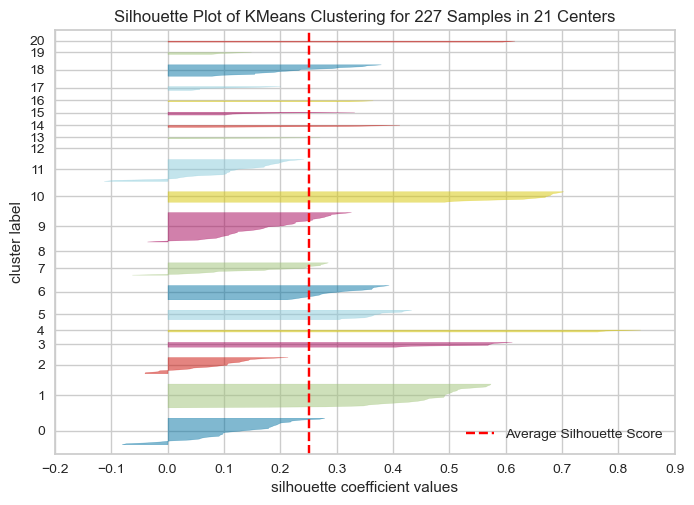

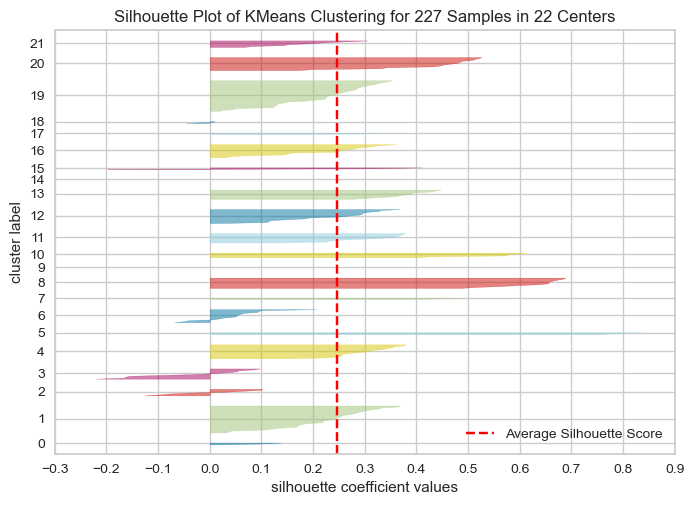

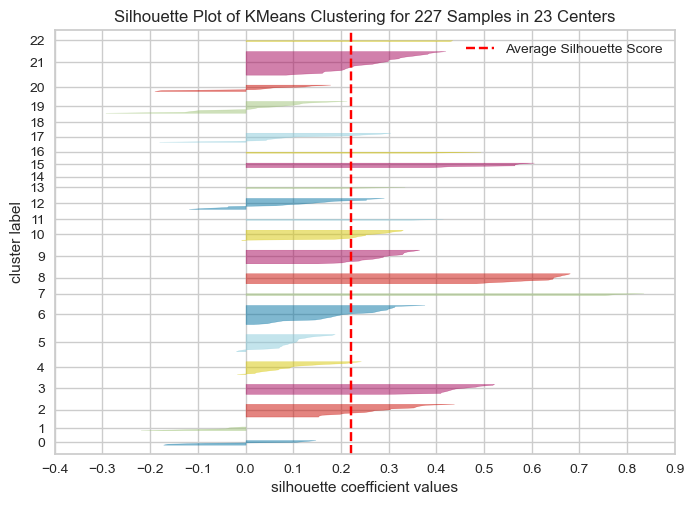

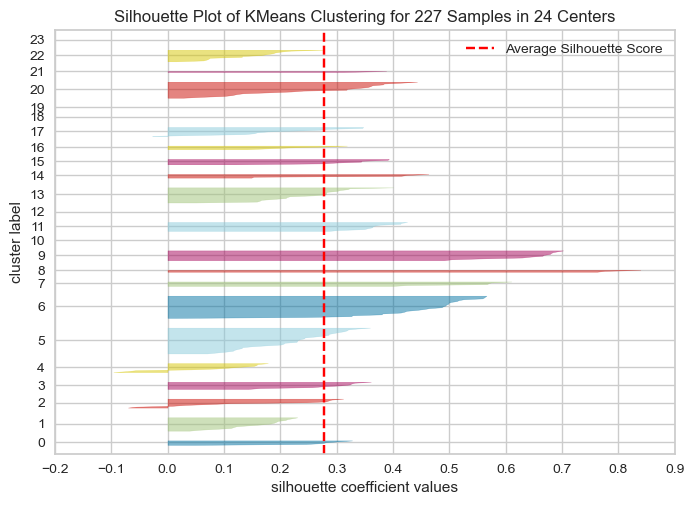

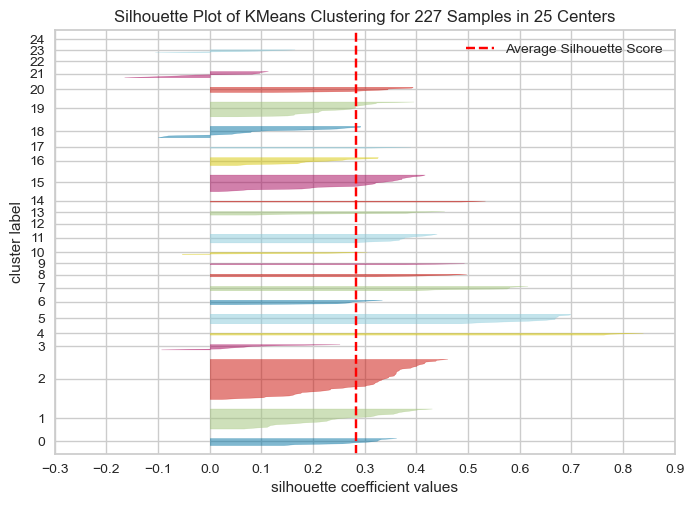

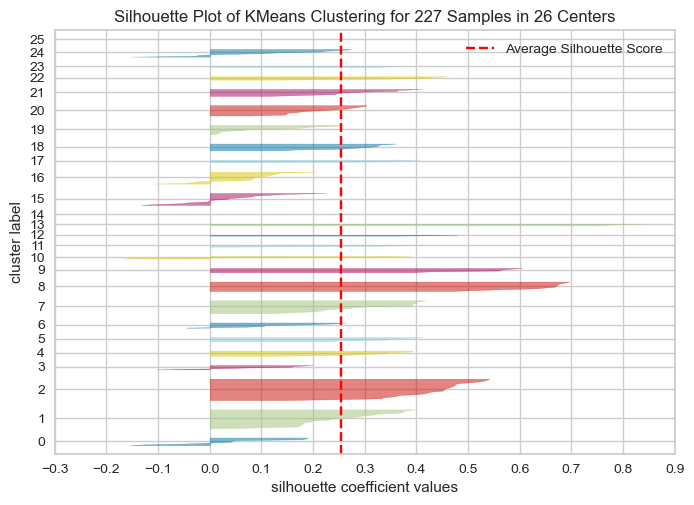

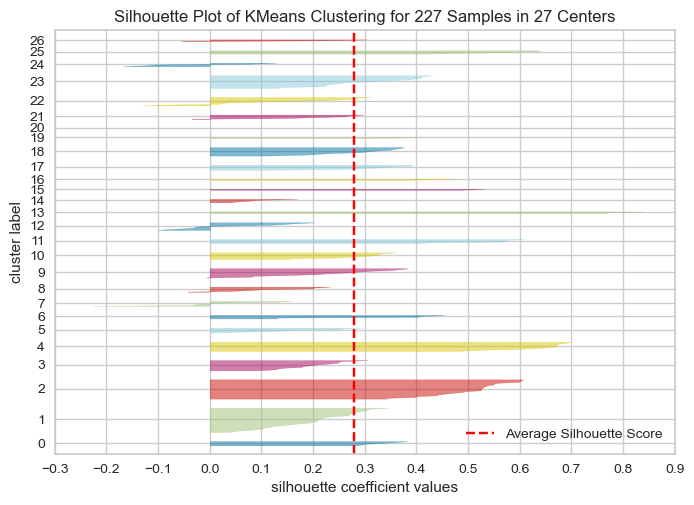

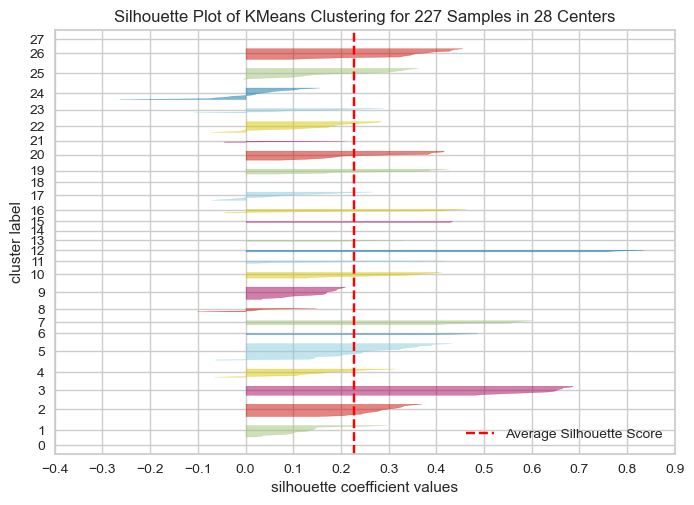

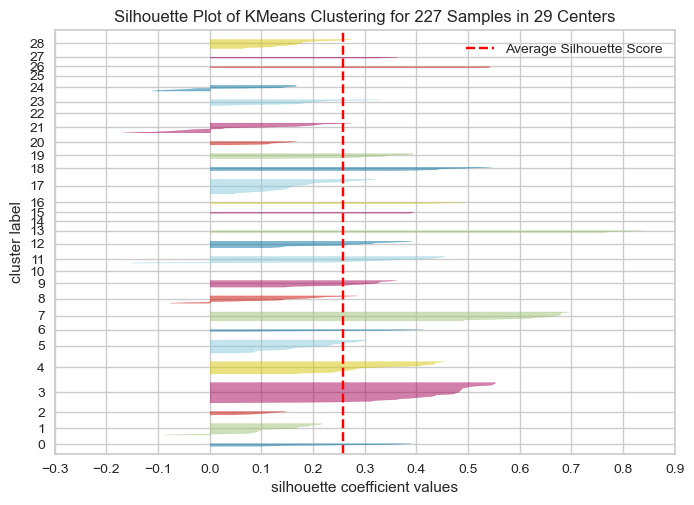

In [111]:
for k in range(2, 30):
    model = KMeans(n_clusters=k)
    vizual = SilhouetteVisualizer(estimator=model, colors='yellowbrick')
    vizual.fit(scaled_X)
    vizual.show();

------------
-------------

# Бонусное задание:
## Географическая интерпретация модели

Результаты этой модели можно очень удобно визуализировать на географической карте! **Замечание: это бонусное задание. В этом задании Вам могут понадобится вещи, которые мы не проходили в лекциях. Если что-то не получается, то не стесняйтесь перейти к блокноту с решениями!**

----
----

**Задание: Создайте кластеры для выбранного значения K. В нашем варианте решений мы думаем, что варианты K=3 или K=15 являются разумными вариантами. Но Вы можете попробовать и другие варианты для количества кластеров.**

In [112]:
iso_codes = pd.read_csv("../DATA/country_iso_codes.csv")

In [113]:
iso_codes

,Country,ISO Code
0,Afghanistan,AFG
1,"Akrotiri and Dhekelia – See United Kingdom, The","Akrotiri and Dhekelia – See United Kingdom, The"
2,Åland Islands,ALA
3,Albania,ALB
4,Algeria,DZA
...,...,...
296,"Congo, Dem. Rep.",COD
297,"Congo, Repub. of the",COG
298,Tanzania,TZA
299,Central African Rep.,CAF


In [114]:
iso_mapping = iso_codes.set_index('Country')['ISO Code'].to_dict()

In [115]:
iso_mapping

{'Afghanistan': 'AFG',
 'Akrotiri and Dhekelia – See United Kingdom, The': 'Akrotiri and Dhekelia – See United Kingdom, The',
 'Åland Islands': 'ALA',
 'Albania': 'ALB',
 'Algeria': 'DZA',
 'American Samoa': 'ASM',
 'Andorra': 'AND',
 'Angola': 'AGO',
 'Anguilla': 'AIA',
 'Antarctica\u200a[a]': 'ATA',
 'Antigua and Barbuda': 'ATG',
 'Argentina': 'ARG',
 'Armenia': 'ARM',
 'Aruba': 'ABW',
 'Ashmore and Cartier Islands – See Australia.': 'Ashmore and Cartier Islands – See Australia.',
 'Australia\u200a[b]': 'AUS',
 'Austria': 'AUT',
 'Azerbaijan': 'AZE',
 'Bahamas (the)': 'BHS',
 'Bahrain': 'BHR',
 'Bangladesh': 'BGD',
 'Barbados': 'BRB',
 'Belarus': 'BLR',
 'Belgium': 'BEL',
 'Belize': 'BLZ',
 'Benin': 'BEN',
 'Bermuda': 'BMU',
 'Bhutan': 'BTN',
 'Bolivia (Plurinational State of)': 'BOL',
 'Bonaire\xa0Sint Eustatius\xa0Saba': 'BES',
 'Bosnia and Herzegovina': 'BIH',
 'Botswana': 'BWA',
 'Bouvet Island': 'BVT',
 'Brazil': 'BRA',
 'British Indian Ocean Territory (the)': 'IOT',
 'British V

In [116]:
df['ISO Code'] = df['Country'].map(iso_mapping)

In [117]:
model = KMeans(n_clusters=8)
model.fit(scaled_X)

KMeans()

In [118]:
df['Cluster'] = model.labels_

In [119]:
import plotly.express as px

fig = px.choropleth(df, locations='ISO Code',
                    color='Cluster',
                    hover_name='Country',
                    color_continuous_scale='Turbo'
                    )
fig.show();

In [120]:
df.corr(numeric_only=True)['Cluster'].abs().sort_values(ascending=False)[1:]

Net migration                         0.468019
GDP ($ per capita)                    0.406149
Phones (per 1000)                     0.253493
Other (%)                             0.211918
Pop. Density (per sq. mi.)            0.185557
Arable (%)                            0.171660
Crops (%)                             0.162123
Agriculture                           0.154942
Climate                               0.146224
Population                            0.126183
Infant mortality (per 1000 births)    0.113421
Deathrate                             0.111588
Service                               0.107475
Birthrate                             0.058110
Coastline (coast/area ratio)          0.053385
Literacy (%)                          0.032075
Industry                              0.028519
Area (sq. mi.)                        0.010641
Name: Cluster, dtype: float64

In [121]:
model = KMeans(n_clusters=5)
model.fit(scaled_X)
df['Cluster'] = model.labels_

fig = px.choropleth(df, locations='ISO Code',
                    color='Cluster',
                    hover_name='Country',
                    color_continuous_scale='Turbo'
                    )
fig.show();

In [122]:
df.corr(numeric_only=True)['Cluster'].abs().sort_values(ascending=False)[1:]

GDP ($ per capita)                    0.483384
Phones (per 1000)                     0.417419
Deathrate                             0.379631
Crops (%)                             0.368932
Climate                               0.362792
Net migration                         0.325044
Arable (%)                            0.230614
Service                               0.209779
Pop. Density (per sq. mi.)            0.187545
Birthrate                             0.187035
Coastline (coast/area ratio)          0.150996
Agriculture                           0.086840
Literacy (%)                          0.080323
Population                            0.040190
Area (sq. mi.)                        0.038272
Infant mortality (per 1000 births)    0.027230
Other (%)                             0.006322
Industry                              0.001816
Name: Cluster, dtype: float64

In [123]:
model = KMeans(n_clusters=10)
model.fit(scaled_X)
df['Cluster'] = model.labels_

fig = px.choropleth(df, locations='ISO Code',
                    color='Cluster',
                    hover_name='Country',
                    color_continuous_scale='Turbo'
                    )
fig.show();

In [124]:
df.corr(numeric_only=True)['Cluster'].abs().sort_values(ascending=False)[1:]

Birthrate                             0.290980
Coastline (coast/area ratio)          0.284754
Pop. Density (per sq. mi.)            0.268182
Deathrate                             0.246328
Infant mortality (per 1000 births)    0.240569
GDP ($ per capita)                    0.213209
Phones (per 1000)                     0.208718
Population                            0.156128
Area (sq. mi.)                        0.153844
Crops (%)                             0.118254
Service                               0.101465
Agriculture                           0.100478
Industry                              0.091955
Other (%)                             0.053031
Literacy (%)                          0.045395
Net migration                         0.034437
Arable (%)                            0.018200
Climate                               0.000805
Name: Cluster, dtype: float64

**Задание: А теперь представьте, что Ваш босс попросил Вас нанести эти страны и кластеры на географическую карту. Сможете ли Вы выяснить, как это делается? В качестве подсказки мы приводим шаги, а также пример того, как выглядит результат:**

1. Выясните, как можно установить библиотеку plotly: https://plotly.com/python/getting-started/

2. Выясните, как можно создать географическую карту choropleth map с помощью plotly: https://plotly.com/python/choropleth-maps/#using-builtin-country-and-state-geometries

3. Вам понадобятся ISO-коды. Либо возьмите их из Википедии, или используйте тот файл, который мы для Вас подготовили: **"../DATA/country_iso_codes.csv"**

4. С помощью номеров кластеров для стран, кодов ISO и названий стран постройте карту мира с помощью plotly.


**Замечание: Это задание моделирует ситуацию, с которой Вы можете столкнуться в работе. У Вас есть конкретная цель, и Вам нужно будет поработать с документацией, чтобы написать решение для этой задачи. Так что Вам нужно будет самостоятельно собрать решение из отдельных кусочков. Если у Вас что-то будет не получаться, то не волнуйтесь! Не стесняйтесь подглядывать в блокнот с решениями.**



---